# Session 4: Neural Networks (MLP & LSTM)


**Learning objectives:**
- Understand how neural networks learn (forward pass, loss, backpropagation)
- Build an MLP (Multi-Layer Perceptron) for tabular data
- Understand the role of Batch Normalisation in stabilising training
- Build an LSTM that exploits the temporal order of monthly features
- Understand when sequence models help and when they don't


**Session plan:**
1. Setup & data preparation
2. Neural network fundamentals (activation, loss, training loop)
3. **Model 1:** MLP on monthly features (flat input)
4. **Model 2:** LSTM on monthly sequences (ordered input)
5. Model comparision
6. Extrapolation test & limitations



---

## Setup & Data Preparation

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import xgboost as xgb
import time
import warnings
import joblib, os
warnings.filterwarnings('ignore')

print(f"PyTorch: {torch.__version__}")

# ── Load data (same as Sessions 1-3) ──
df = pd.read_parquet("./data/wheat_features.parquet")
df = df[df['wheat_yield'] > 0].copy()  

print(f"\nDataset: {df.shape[0]:,} rows x {df.shape[1]} columns")  

PyTorch: 2.10.0+cu128

Dataset: 227,436 rows x 57 columns


In [9]:
# Flag suspect

suspect = (df['wheat_yield'] < 0.01) & (df['sowing_doy'] > 0)
print(f"Suspect zero-yield rows (sown but yield=0): {suspect.sum()}")
 
#  Window-median replacement
WINDOW = 3   # years on each side
 
def replace_zeros_window_median(series: pd.Series,
                                 suspect_mask: pd.Series,
                                 window: int = WINDOW) -> pd.Series:
    """
    For each flagged position, compute the median of up to `window`
    valid (non-zero, non-NaN) neighbours on each side in the time series.
    Falls back to the cell-wide positive median if fewer than 2 neighbours exist.
    """
    s = series.copy().astype(float)
    fallback_median = s[s > 0].median()
 
    for idx in s.index[suspect_mask.reindex(s.index, fill_value=False)]:
        pos = s.index.get_loc(idx)
 
        left  = [v for v in s.iloc[max(0, pos - window): pos]        if v > 0]
        right = [v for v in s.iloc[pos + 1: pos + 1 + window]        if v > 0]
        neighbours = left + right
 
        if len(neighbours) >= 2:
            s.iloc[pos] = np.median(neighbours)
        else:
            #  not enough neighbours → use cell-wide median
            s.iloc[pos] = fallback_median
 
    return s
 
 
df['wheat_yield'] = (
    df.groupby(['lat', 'lon'], group_keys=False)
    .apply(lambda g: replace_zeros_window_median(
        g['wheat_yield'],
        suspect.loc[g.index]
    ))
)


Suspect zero-yield rows (sown but yield=0): 316


In [10]:
#  Metrics evaluation
def concordance_cc(actual, predicted):
    mean_act  = np.mean(actual)
    mean_pred = np.mean(predicted)
    var_act   = np.var(actual)
    var_pred  = np.var(predicted)
    covariance = np.mean((actual - mean_act) * (predicted - mean_pred))
    return (2 * covariance) / (var_act + var_pred + (mean_act - mean_pred)**2)

def eval_model(name, actual, predicted):
    r2   = r2_score(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mae  = mean_absolute_error(actual, predicted)
    bias = np.mean(predicted - actual)
    lccc = concordance_cc(actual, predicted)
    print(f"  {name:<30s} R2={r2:.3f}  RMSE={rmse:.3f}  MAE={mae:.3f}  Bias={bias:+.3f}  LCCC={lccc:.3f}")
    return {"name": name, "R2": r2, "RMSE": rmse, "MAE": mae, "Bias": bias, "LCCC": lccc}


In [11]:

FEATURE_COLS = ['pawc_0_30_mm',  'ph_0_30','rain_preseason', 'rain_early', 'rain_late',
                'gdd_may_nov', 'frost_days_aug_oct', 'heat_days_aug_oct',  'rad_aug_oct', 'fasw_mean_aug_oct']


monthly_rain = [c for c in df.columns if c.startswith("rain_m") or c.startswith("rain_mpre")]
monthly_rad  = [c for c in df.columns if c.startswith("rad_sum_m")]
monthly_fasw = [c for c in df.columns if c.startswith("fasw_mean_m") and "aug" not in c]
monthly_gdd  = [c for c in df.columns if c.startswith("gdd_m")]
soil_feats   = ["pawc_0_30_mm", "ph_0_30"]
augoct_feats = [c for c in ["frost_days_aug_oct","heat_days_aug_oct",
                             "rad_aug_oct","fasw_mean_aug_oct"] if c in df.columns]

MONTHLY_FEATURES = soil_feats + monthly_rain + monthly_rad + monthly_fasw + monthly_gdd + augoct_feats
MONTHLY_FEATURES = [f for f in MONTHLY_FEATURES if f in df.columns]

# Temporal split 
train = df[df['year'] <= 2018]
test  = df[df['year'] >= 2019]

X_train_raw = train[MONTHLY_FEATURES].values.astype(np.float32)
X_test_raw  = test[MONTHLY_FEATURES].values.astype(np.float32)
y_train_raw = train['wheat_yield'].values.astype(np.float32)
y_test_raw  = test['wheat_yield'].values.astype(np.float32)

for i in range(X_train_raw.shape[1]):
    med = np.nanmedian(X_train_raw[:, i])
    X_train_raw[np.isnan(X_train_raw[:, i]), i] = med
    X_test_raw[np.isnan(X_test_raw[:, i]), i] = med

print(f"Features: {len(MONTHLY_FEATURES)}")
print(f"Train: {len(X_train_raw):,}  Test: {len(X_test_raw):,}")

Features: 49
Train: 213,212  Test: 14,224


### Why do we need to do feature scaling in NN?
Unlike tree-based models (RF, XGBoost), neural networks are sensitive to feature scales.
A feature in range [0, 500] (rainfall mm) would dominate one in range [0, 1] (FASW).

**StandardScaler** transforms each feature to mean=0, std=1.

**Important:** Fit the scaler on training data only, then transform both train and test.


In [12]:
# Scale features (critical for neural networks!!!!) 
scaler_X = StandardScaler()
X_train = scaler_X.fit_transform(X_train_raw)   # fit on train only
X_test  = scaler_X.transform(X_test_raw)         # transform test with train stats

# Also scale target 
scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train_raw.reshape(-1, 1)).flatten()
y_test_scaled  = scaler_y.transform(y_test_raw.reshape(-1, 1)).flatten()

print(f"Before scaling: rain_m0 range [{X_train_raw[:, MONTHLY_FEATURES.index('rain_m0') if 'rain_m0' in MONTHLY_FEATURES else 0].min():.0f}, "
      f"{X_train_raw[:, MONTHLY_FEATURES.index('rain_m0') if 'rain_m0' in MONTHLY_FEATURES else 0].max():.0f}]")
print(f"After scaling:  rain_m0 range [{X_train[:, MONTHLY_FEATURES.index('rain_m0') if 'rain_m0' in MONTHLY_FEATURES else 0].min():.2f}, "
      f"{X_train[:, MONTHLY_FEATURES.index('rain_m0') if 'rain_m0' in MONTHLY_FEATURES else 0].max():.2f}]")
print(f"Target: mean={y_train_scaled.mean():.3f}, std={y_train_scaled.std():.3f}")

Before scaling: rain_m0 range [0, 296]
After scaling:  rain_m0 range [-1.38, 9.68]
Target: mean=0.000, std=1.000




### How a NN works

```
Input features → [Hidden Layer 1] → [Hidden Layer 2] → Output (yield)
     (50)           (128 neurons)      (64 neurons)       (1)
```

Each neuron computes: **output = activation(weights × inputs + bias)**

### Key Concepts

| Concept | What it does |
|---------|-------------|
| **Weights** | Learnable parameters that multiply inputs |
| **Bias** | Learnable offset added to each neuron |
| **Activation function** | Introduces non-linearity (ReLU, Tanh) |
| **Loss function** | Measures how wrong predictions are (MSE) |
| **Backpropagation** | Computes gradients of loss w.r.t. weights |
| **Optimizer** | Updates weights to reduce loss (Adam) |
| **Epoch** | One pass through all training data |
| **Batch size** | Number of samples processed before updating weights |

### Why activation function matters?

Without activation functions, stacking layers = one big linear model (no better than OLS!).
**ReLU(x) = max(0, x)** is the most common — simple but effective.


##  MLP 

An MLP treats all features as a **flat vector** — it doesn't know that `rain_m0`, `rain_m1`, ..., `rain_m8`
are a time sequence. It just sees 50 numbers.


In [13]:
# Define MLP architecture 
class WheatMLP(nn.Module):
    def __init__(self, n_features, hidden1=128, hidden2=64, dropout=0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_features, hidden1),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden1, hidden2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden2, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)

model_mlp = WheatMLP(n_features=len(MONTHLY_FEATURES))
print(model_mlp)
n_params = sum(p.numel() for p in model_mlp.parameters())
print(f"\nTotal parameters: {n_params:,}")


WheatMLP(
  (net): Sequential(
    (0): Linear(in_features=49, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=64, out_features=32, bias=True)
    (7): ReLU()
    (8): Linear(in_features=32, out_features=1, bias=True)
  )
)

Total parameters: 16,769


In [14]:
#  Prepare PyTorch datasets 
X_train_t = torch.FloatTensor(X_train)
y_train_t = torch.FloatTensor(y_train_scaled)
X_test_t  = torch.FloatTensor(X_test)
y_test_t  = torch.FloatTensor(y_test_scaled)

train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader  = DataLoader(train_dataset, batch_size=512, shuffle=True)

print(f"Training batches: {len(train_loader)} (batch_size=512)")

Training batches: 417 (batch_size=512)


In [15]:
# Training loop 
def train_model(model, train_loader, X_val, y_val, n_epochs=100, lr=0.001, patience=15):
    """Train with early stopping on validation loss."""
    model = model
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    # Validation data
    X_val_t = torch.FloatTensor(X_val)
    y_val_t = torch.FloatTensor(y_val)

    train_losses, val_losses = [], []
    best_val_loss = float('inf')
    best_state = None
    patience_counter = 0

    for epoch in range(n_epochs):
        # Training 
        model.train()
        epoch_loss = 0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch, y_batch
            optimizer.zero_grad()
            pred = model(X_batch)
            loss = criterion(pred, y_batch)
            loss.backward()          # backpropagation!
            optimizer.step()         # update weights
            epoch_loss += loss.item() * len(X_batch)
        train_losses.append(epoch_loss / len(train_loader.dataset))

        #  Validation 
        model.eval()
        with torch.no_grad():
            val_pred = model(X_val_t)
            val_loss = criterion(val_pred, y_val_t).item()
        val_losses.append(val_loss)

        # Early stopping 
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"  Early stopping at epoch {epoch+1}")
                break

        if (epoch + 1) % 20 == 0:
            print(f"  Epoch {epoch+1:3d}: train_loss={train_losses[-1]:.4f}  val_loss={val_loss:.4f}")

    model.load_state_dict(best_state)
    return model, train_losses, val_losses

In [16]:
#  Reload 
mlp = WheatMLP(n_features=X_train.shape[1])
mlp.load_state_dict(torch.load('./models/mlp_wheat.pth'))
mlp_losses = joblib.load('./models/mlp_losses.joblib')
train_losses = mlp_losses['train']
val_losses = mlp_losses['val']

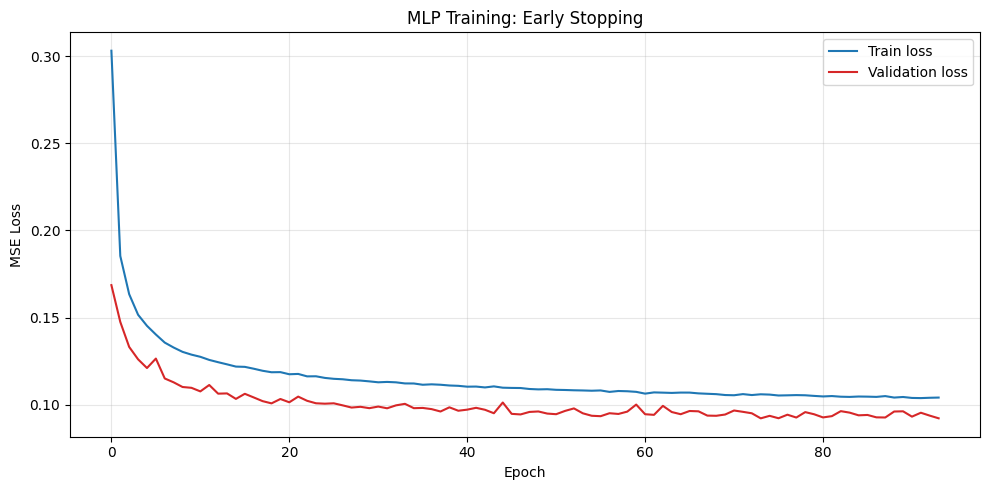

Best epoch: 74 (val_loss=0.0922)


In [17]:
# Learning curve 
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(train_losses, label="Train loss", color="tab:blue")
ax.plot(val_losses, label="Validation loss", color="tab:red")
ax.set_xlabel("Epoch"); ax.set_ylabel("MSE Loss")
ax.set_title("MLP Training: Early Stopping")
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print(f"Best epoch: {np.argmin(val_losses)+1} (val_loss={min(val_losses):.4f})")

In [18]:
#  Evaluate MLP 
mlp.eval()
scaler_y = joblib.load('./models/scaler_y.joblib')

with torch.no_grad():
    pred_mlp_scaled = mlp(torch.FloatTensor(X_test)).detach().numpy()

pred_mlp = scaler_y.inverse_transform(pred_mlp_scaled.reshape(-1, 1)).flatten()
pred_mlp = np.clip(pred_mlp, 0, None)

print("=== MLP (monthly features) ===")
m_mlp = eval_model("MLP", y_test_raw, pred_mlp)

=== MLP (monthly features) ===
  MLP                            R2=0.822  RMSE=0.372  MAE=0.288  Bias=+0.049  LCCC=0.892


---
## Exercise: Add Batch Normalisation to WheatMLP

The current `WheatMLP` uses only `ReLU` and `Dropout` between layers.
**Batch Normalisation** (`nn.BatchNorm1d`) can be inserted between the linear
layer and the activation to stabilise training.

The correct order is:
```
nn.Linear  →  nn.BatchNorm1d  →  nn.ReLU  →  nn.Dropout
```

The number passed to `BatchNorm1d` must match the **output size** of the
preceding `Linear` layer (e.g. `nn.BatchNorm1d(128)` after `nn.Linear(..., 128)`).

> **Note:** Do **not** add BatchNorm to the final output layer — it would
> distort the yield prediction.

---

**Your task**

1. Include `BatchNorm1d` in the structure of MLP model
2. Train it using the same `train_model` function
3. Compare the learning curves and test metrics against the original MLP

**Questions:**
- Does training converge faster (fewer epochs)?
- Is the validation loss lower or higher?
- Does the test R² improve?

---
## LSTM 

### MLP vs LSTM

The MLP sees all features as a flat bag of numbers. But our monthly features have a
**natural time order**: `rain_m0` → `rain_m1` → ... → `rain_m8` is a sequence through
the growing season.

**LSTM** (Long Short-Term Memory) processes features as a **sequence**, learning patterns
like "dry early season followed by wet late season" or "gradually declining soil moisture."

```
MLP:  [rain_m0, rain_m1, ..., fasw_m8, pawc, ph]  →  flat vector  →  yield

LSTM: [month0: rain, rad, fasw, gdd]  →  sequence  →  yield
      [month1: rain, rad, fasw, gdd]       ↓
      [month2: rain, rad, fasw, gdd]     LSTM cells
      ...                                  ↓
      [month8: rain, rad, fasw, gdd]  →  final state → yield
```

The LSTM processes one month at a time, building up a "memory" of the season so far.


In [19]:
# Reshape data for LSTM: (samples, timesteps, features_per_step)
# We'll create a 9-step sequence (m0..m8) with rain + rad + fasw + gdd per step
# Plus static features (soil, aug-oct stress) concatenated at the end

# Monthly sequence variables (9 months post-sowing)
seq_vars = {}
for prefix, cols in [("rain", monthly_rain), ("rad", monthly_rad),
                      ("fasw", monthly_fasw), ("gdd", monthly_gdd)]:
    # Get only post-sowing monthly columns (m0..m8)
    post = sorted([c for c in cols if c.startswith(f"{prefix.replace('rad','rad_sum').replace('fasw','fasw_mean')}_m")
                   and "pre" not in c])
    if not post:
        post = sorted([c for c in cols if "_m" in c and "pre" not in c])
    seq_vars[prefix] = post

# Find common number of timesteps
n_steps = min(len(v) for v in seq_vars.values() if v)
print(f"Sequence length: {n_steps} months")
for k, v in seq_vars.items():
    print(f"  {k}: {v[:n_steps]}")

# Static features (not part of the sequence)
static_cols = soil_feats + augoct_feats + [c for c in monthly_rain if "pre" in c]
static_cols = [c for c in static_cols if c in MONTHLY_FEATURES]
print(f"\nStatic features: {len(static_cols)}")

Sequence length: 9 months
  rain: ['rain_m0', 'rain_m1', 'rain_m2', 'rain_m3', 'rain_m4', 'rain_m5', 'rain_m6', 'rain_m7', 'rain_m8']
  rad: ['rad_sum_m0', 'rad_sum_m1', 'rad_sum_m2', 'rad_sum_m3', 'rad_sum_m4', 'rad_sum_m5', 'rad_sum_m6', 'rad_sum_m7', 'rad_sum_m8']
  fasw: ['fasw_mean_m0', 'fasw_mean_m1', 'fasw_mean_m2', 'fasw_mean_m3', 'fasw_mean_m4', 'fasw_mean_m5', 'fasw_mean_m6', 'fasw_mean_m7', 'fasw_mean_m8']
  gdd: ['gdd_m0', 'gdd_m1', 'gdd_m2', 'gdd_m3', 'gdd_m4', 'gdd_m5', 'gdd_m6', 'gdd_m7', 'gdd_m8']

Static features: 12


In [20]:
# Build sequence arrays 
def build_sequences(data_df, seq_vars, static_cols, n_steps, scaler_X_fit=None):
    """Reshape flat features into (samples, timesteps, channels) + static."""
    # Sequence: (samples, n_steps, n_channels)
    channels = []
    for prefix, cols in seq_vars.items():
        cols_use = cols[:n_steps]
        vals = data_df[cols_use].values.astype(np.float32)
        channels.append(vals)

    seq = np.stack(channels, axis=-1)  # (samples, n_steps, n_channels)

    # Static: (samples, n_static)
    static = data_df[static_cols].values.astype(np.float32)

    # Fill NaN
    for i in range(seq.shape[2]):
        med = np.nanmedian(seq[:, :, i])
        seq[np.isnan(seq[:, :, i])] = med if not np.isnan(med) else 0
    for i in range(static.shape[1]):
        med = np.nanmedian(static[:, i])
        static[np.isnan(static[:, i]), i] = med if not np.isnan(med) else 0

    return seq, static

seq_train, static_train = build_sequences(train, seq_vars, static_cols, n_steps)
seq_test,  static_test  = build_sequences(test, seq_vars, static_cols, n_steps)

# Scale sequences
n_channels = seq_train.shape[2]
seq_scalers = []
for ch in range(n_channels):
    s = StandardScaler()
    seq_train[:, :, ch] = s.fit_transform(seq_train[:, :, ch])
    seq_test[:, :, ch]  = s.transform(seq_test[:, :, ch])
    seq_scalers.append(s)

static_scaler = StandardScaler()
static_train = static_scaler.fit_transform(static_train)
static_test  = static_scaler.transform(static_test)

print(f"Sequence shape: {seq_train.shape}  (samples, timesteps, channels)")
print(f"Static shape:   {static_train.shape}")

Sequence shape: (213212, 9, 4)  (samples, timesteps, channels)
Static shape:   (213212, 12)


In [21]:
# Define LSTM model
class WheatLSTM(nn.Module):
    def __init__(self, n_channels, n_static, hidden_size=64, n_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=n_channels,
            hidden_size=hidden_size,
            num_layers=n_layers,
            batch_first=True,
            dropout=dropout if n_layers > 1 else 0
        )
        # Combine LSTM output with static features
        self.head = nn.Sequential(
            nn.Linear(hidden_size + n_static, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, seq, static):
        # seq: (batch, timesteps, channels)
        lstm_out, (h_n, c_n) = self.lstm(seq)
        last_hidden = lstm_out[:, -1, :]  # take last timestep output
        combined = torch.cat([last_hidden, static], dim=1)
        return self.head(combined).squeeze(-1)

n_ch = seq_train.shape[2]
n_st = static_train.shape[1]
model_lstm = WheatLSTM(n_channels=n_ch, n_static=n_st)
print(model_lstm)
print(f"\nParameters: {sum(p.numel() for p in model_lstm.parameters()):,}")

WheatLSTM(
  (lstm): LSTM(4, 64, num_layers=2, batch_first=True, dropout=0.2)
  (head): Sequential(
    (0): Linear(in_features=76, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Linear(in_features=32, out_features=1, bias=True)
  )
)

Parameters: 58,241


**Note**: It took a longer time to train LSTM (and neural networks in general) on CPUs. It is better to use GPUs

In [22]:
# Train LSTM
def train_lstm(model, seq_tr, static_tr, y_tr, seq_val, static_val, y_val,
               n_epochs=150, lr=0.001, batch_size=512, patience=20):
    model = model
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    # Validation tensors
    seq_val_t = torch.FloatTensor(seq_val)
    sta_val_t = torch.FloatTensor(static_val)
    y_val_t   = torch.FloatTensor(y_val)

    dataset = TensorDataset(torch.FloatTensor(seq_tr), torch.FloatTensor(static_tr),
                             torch.FloatTensor(y_tr))
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    train_losses, val_losses = [], []
    best_val, best_state, wait = float('inf'), None, 0

    for epoch in range(n_epochs):
        model.train()
        ep_loss = 0
        for seq_b, sta_b, y_b in loader:
            seq_b, sta_b, y_b = seq_b, sta_b, y_b
            optimizer.zero_grad()
            pred = model(seq_b, sta_b)
            loss = criterion(pred, y_b)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # prevent exploding gradients
            optimizer.step()
            ep_loss += loss.item() * len(y_b)
        train_losses.append(ep_loss / len(dataset))

        model.eval()
        with torch.no_grad():
            vp = model(seq_val_t, sta_val_t)
            vl = criterion(vp, y_val_t).item()
        val_losses.append(vl)

        if vl < best_val:
            best_val = vl
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                print(f"  Early stopping at epoch {epoch+1}")
                break

        if (epoch + 1) % 25 == 0:
            print(f"  Epoch {epoch+1:3d}: train={train_losses[-1]:.4f}  val={vl:.4f}")

    model.load_state_dict(best_state)
    return model, train_losses, val_losses

# Split train into train + val
from sklearn.model_selection import train_test_split
idx_tr, idx_val = train_test_split(np.arange(len(seq_train)), test_size=0.15, random_state=42)

print("Training LSTM...")
t0 = time.time()
lstm = WheatLSTM(n_channels=n_ch, n_static=n_st)


Training LSTM...


In [23]:
#  Reload LSTM
lstm = WheatLSTM(n_channels=n_ch, n_static=n_st)
lstm.load_state_dict(torch.load('./models/lstm_wheat.pth'))
lstm_losses = joblib.load('./models/lstm_losses.joblib')
lstm_tl = lstm_losses['train']
lstm_vl = lstm_losses['val']

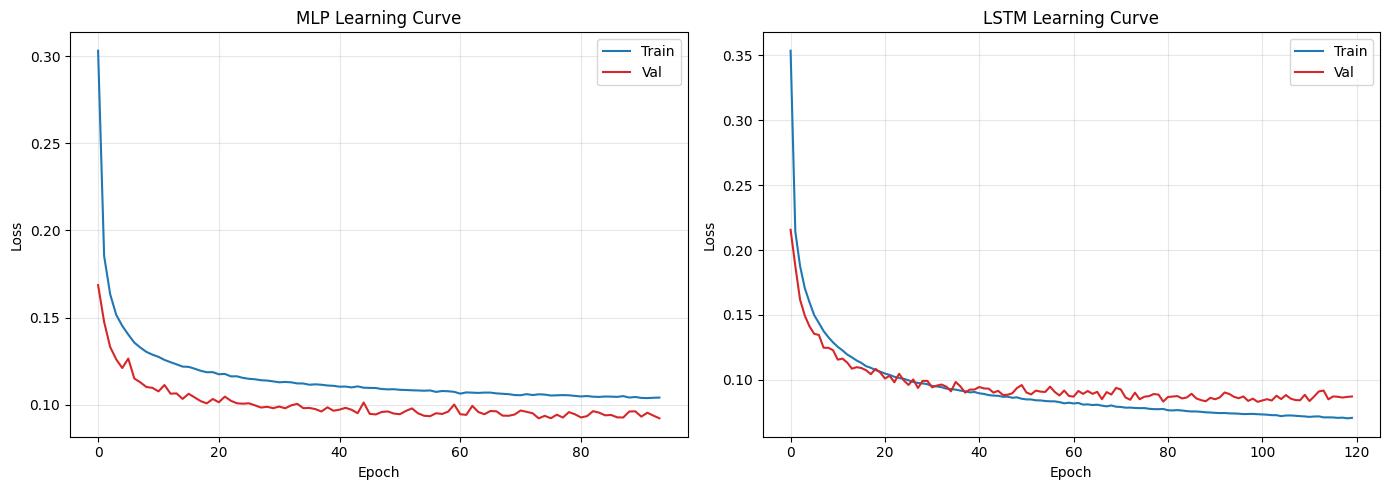

In [24]:
# Learning curves side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(train_losses, label="Train", color="tab:blue")
axes[0].plot(val_losses, label="Val", color="tab:red")
axes[0].set_title("MLP Learning Curve"); axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss"); axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(lstm_tl, label="Train", color="tab:blue")
axes[1].plot(lstm_vl, label="Val", color="tab:red")
axes[1].set_title("LSTM Learning Curve"); axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss"); axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [25]:
# Evaluate
lstm.eval()
scaler_y = joblib.load('./models/scaler_y.joblib')
with torch.no_grad():
    seq_t = torch.FloatTensor(seq_test)
    sta_t = torch.FloatTensor(static_test)
    pred_lstm_scaled = lstm(seq_t, sta_t).detach().numpy()

pred_lstm = scaler_y.inverse_transform(pred_lstm_scaled.reshape(-1, 1)).flatten()
pred_lstm = np.clip(pred_lstm, 0, None)

print("=== LSTM (monthly sequence) ===")
m_lstm = eval_model("LSTM", y_test_raw, pred_lstm)


=== LSTM (monthly sequence) ===
  LSTM                           R2=0.760  RMSE=0.432  MAE=0.343  Bias=+0.116  LCCC=0.852


## Full model comparison 




In [26]:
# Reproduce RF and XGBoost
# RF

rf = joblib.load('./models/rf_monthly.joblib')
pred_rf = rf.predict(X_test_raw)
m_rf = eval_model(f"RF ({len(MONTHLY_FEATURES)} feat)", y_test_raw, pred_rf)
# XGBoost

xgb = joblib.load('./models/xgb_monthly.joblib')
pred_xgb = xgb.predict(X_test_raw)
m_xgb = eval_model(f"XGBoost ({len(MONTHLY_FEATURES)} feat)", y_test_raw, pred_xgb)


  RF (49 feat)                   R2=0.740  RMSE=0.450  MAE=0.356  Bias=+0.112  LCCC=0.837
  XGBoost (49 feat)              R2=0.791  RMSE=0.404  MAE=0.311  Bias=+0.067  LCCC=0.874


In [27]:
# Comparison
all_models = [m_rf, m_xgb, m_mlp, m_lstm]

print("=" * 85)
print("FULL MODEL COMPARISON")
print("=" * 85)
print(f"{'Model':<35s} {'R2':>6s} {'RMSE':>7s} {'MAE':>7s} {'Bias':>7s} {'LCCC':>6s}")
print("-" * 85)
for m in all_models:
    print(f"{m['name']:<35s} {m['R2']:6.3f} {m['RMSE']:7.3f} {m['MAE']:7.3f} {m['Bias']:+7.3f} {m['LCCC']:6.3f}")

best = max(all_models, key=lambda x: x['R2'])
print(f"\nBest model: {best['name']} (R2={best['R2']:.3f})")

FULL MODEL COMPARISON
Model                                   R2    RMSE     MAE    Bias   LCCC
-------------------------------------------------------------------------------------
RF (49 feat)                         0.740   0.450   0.356  +0.112  0.837
XGBoost (49 feat)                    0.791   0.404   0.311  +0.067  0.874
MLP                                  0.822   0.372   0.288  +0.049  0.892
LSTM                                 0.760   0.432   0.343  +0.116  0.852

Best model: MLP (R2=0.822)


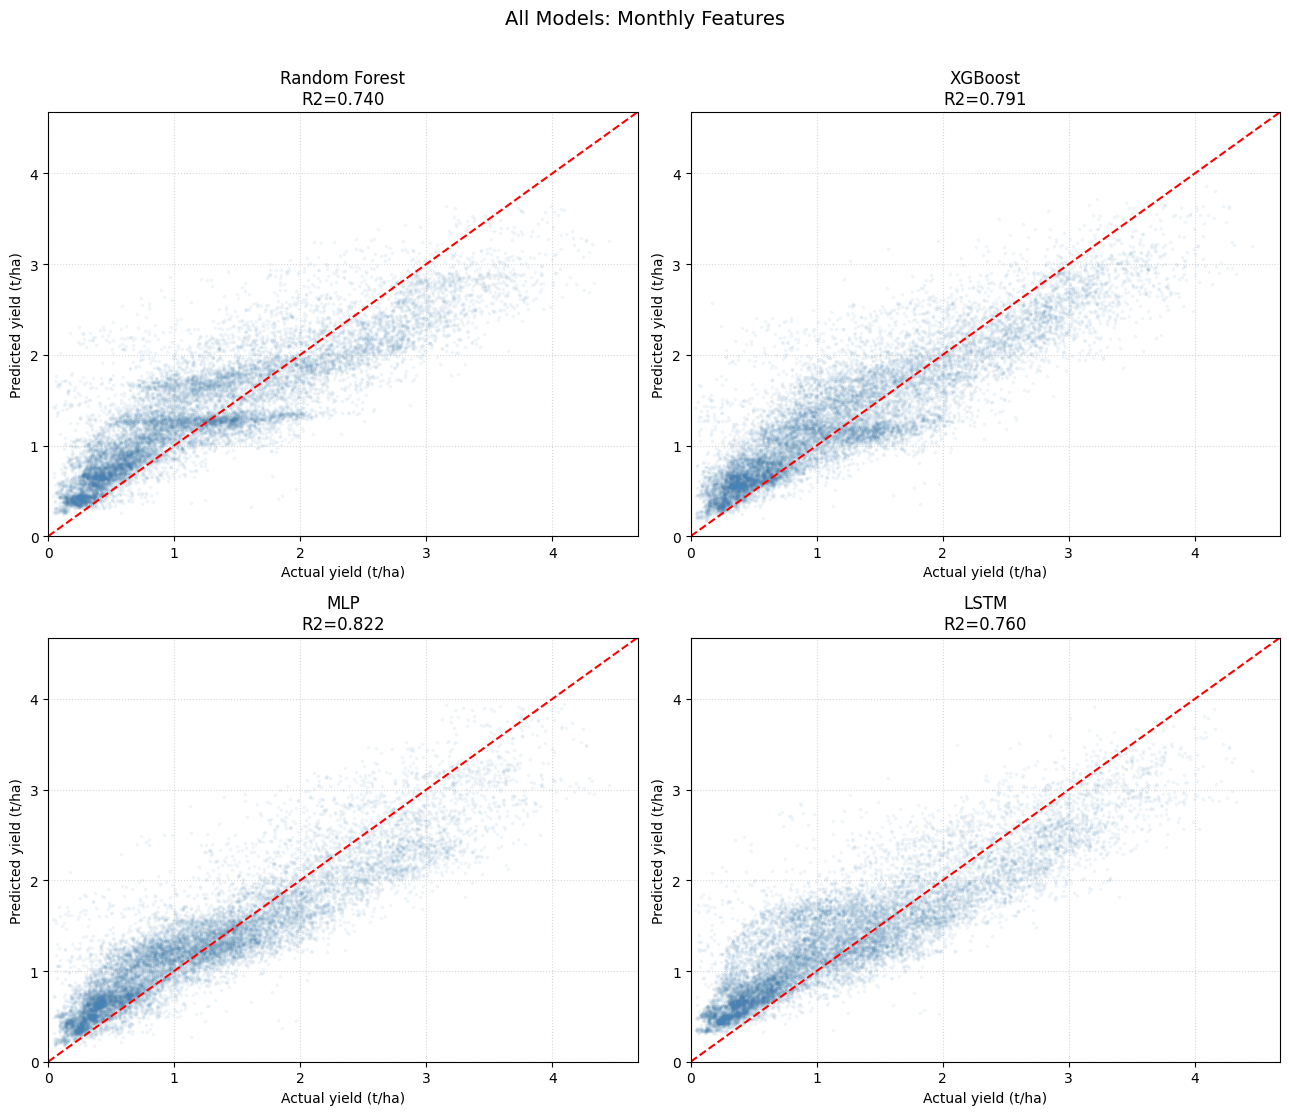

In [28]:
# Scatter
fig, axes = plt.subplots(2, 2, figsize=(13, 11))

for ax, (name, pred, r2) in zip(axes.flat, [
    ("Random Forest", pred_rf, m_rf['R2']),
    ("XGBoost", pred_xgb, m_xgb['R2']),
    ("MLP", pred_mlp, m_mlp['R2']),
    ("LSTM", pred_lstm, m_lstm['R2']),
]):
    ax.scatter(y_test_raw, pred, alpha=0.05, s=3, color='steelblue')
    lim = max(y_test_raw.max(), pred.max()) * 1.05
    ax.plot([0, lim], [0, lim], 'r--', linewidth=1.5)
    ax.set_xlabel('Actual yield (t/ha)')
    ax.set_ylabel('Predicted yield (t/ha)')
    ax.set_title(f'{name}\nR2={r2:.3f}')
    ax.grid(True, linestyle=':', alpha=0.5)
    ax.set_xlim(0, lim); ax.set_ylim(0, lim)

plt.suptitle("All Models: Monthly Features", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [29]:
# Per-year comparison
test_years = test['year'].values
print("=== Per-year performance ===")
for yr in [2019, 2020]:
    m = test_years == yr
    print(f"\n  Year {yr} (n={m.sum():,}):")
    for name, pred in [("RF", pred_rf), ("XGBoost", pred_xgb),
                        ("MLP", pred_mlp), ("LSTM", pred_lstm)]:
        r2 = r2_score(y_test_raw[m], pred[m])
        rmse = np.sqrt(mean_squared_error(y_test_raw[m], pred[m]))
        print(f"    {name:<12s} R2={r2:.3f}  RMSE={rmse:.3f}")

=== Per-year performance ===

  Year 2019 (n=7,112):
    RF           R2=0.611  RMSE=0.490
    XGBoost      R2=0.678  RMSE=0.445
    MLP          R2=0.774  RMSE=0.373
    LSTM         R2=0.639  RMSE=0.472

  Year 2020 (n=7,112):
    RF           R2=0.815  RMSE=0.406
    XGBoost      R2=0.857  RMSE=0.357
    MLP          R2=0.846  RMSE=0.371
    LSTM         R2=0.832  RMSE=0.387


## Limitation

All these models learn from historical data (1989–2018). What happens if we ask
them to predict yields under conditions **outside the training range**?

This is critical for climate change applications.


In [30]:
#  Extrapolation test: what if rainfall doubles? 
X_test_extreme = X_test_raw.copy()

# Find rainfall columns and double them
rain_cols_idx = [i for i, c in enumerate(MONTHLY_FEATURES) if c.startswith("rain")]
for idx in rain_cols_idx:
    X_test_extreme[:, idx] *= 2.0

# Tree models
pred_rf_ext  = rf.predict(X_test_extreme)
pred_xgb_ext = xgb.predict(X_test_extreme)

# Neural networks (need to scale)
X_test_ext_scaled = scaler_X.transform(X_test_extreme)
with torch.no_grad():
    pred_mlp_ext_s = mlp(torch.FloatTensor(X_test_ext_scaled)).detach().numpy()
pred_mlp_ext = scaler_y.inverse_transform(pred_mlp_ext_s.reshape(-1, 1)).flatten()

print("=== Extrapolation: What if all rainfall doubles? ===")
print(f"{'Model':<15s} {'Normal mean':>12s} {'2x Rain mean':>12s} {'Change':>10s}")
print("-" * 55)
for name, pred_n, pred_e in [
    ("RF", pred_rf, pred_rf_ext),
    ("XGBoost", pred_xgb, pred_xgb_ext),
    ("MLP", pred_mlp, pred_mlp_ext),
]:
    print(f"{name:<15s} {np.mean(pred_n):12.2f} {np.mean(pred_e):12.2f} {np.mean(pred_e)-np.mean(pred_n):+10.2f}")

print()


=== Extrapolation: What if all rainfall doubles? ===
Model            Normal mean 2x Rain mean     Change
-------------------------------------------------------
RF                      1.39         1.62      +0.22
XGBoost                 1.35         1.57      +0.22
MLP                     1.33         1.51      +0.18



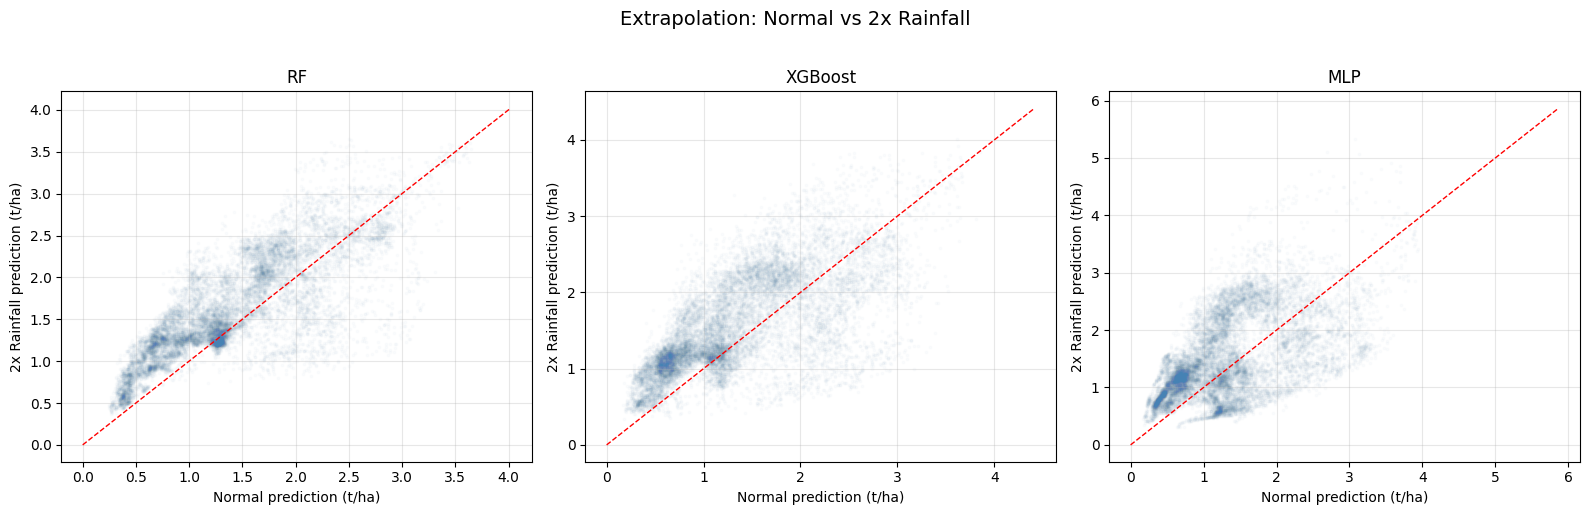

In [31]:

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (name, pred_n, pred_e) in zip(axes, [
    ("RF", pred_rf, pred_rf_ext),
    ("XGBoost", pred_xgb, pred_xgb_ext),
    ("MLP", pred_mlp, pred_mlp_ext),
]):
    ax.scatter(pred_n, pred_e, alpha=0.02, s=3, color='steelblue')
    lim = max(pred_n.max(), pred_e.max()) * 1.1
    ax.plot([0, lim], [0, lim], 'r--', linewidth=1)
    ax.set_xlabel('Normal prediction (t/ha)')
    ax.set_ylabel('2x Rainfall prediction (t/ha)')
    ax.set_title(name)
    ax.grid(True, alpha=0.3)

plt.suptitle("Extrapolation: Normal vs 2x Rainfall", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()



## Summary

### Model Comparison

| Model | Type | Temporal awareness | Extrapolation | Explainability |
|-------|------|-------------------|---------------|----------------|
| **RF** | Ensemble (bagging) | No | Cannot | Feature importance |
| **XGBoost** | Ensemble (boosting) | No | Cannot | SHAP values |
| **MLP** | Neural network | No (flat input) | Can (risky) | Limited |
| **LSTM** | Neural network | Yes (sequence) | Can (risky) | Very limited |

### Exercises
1. Try increasing MLP depth (add a 4th hidden layer). Does it help?
2. Change LSTM `hidden_size` to 128 and `n_layers` to 3. Better or worse?

